<a href="https://colab.research.google.com/github/sanketJ-ai/PDS-Practical-/blob/main/p_09_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRACTICAL 9

NAME: Sanket Jadhav
CLASS:SY-A
ROLLNO: A-43



Aim - Building a Simple Data Science Pipeline: Integrate all learned techniques in
previous labs into a complete workflow.
Q1. What is a Data Science Pipeline?
A Data Science Pipeline is a step-by-step process used to convert raw data into useful
results or predictions.
Stages: Data Collection – collecting data (CSV, database) Data Cleaning – removing
missing or wrong data EDA (Exploration) – understanding patterns in data Feature
Engineering – creating new useful columns Encoding & Scaling – converting data into
proper format Model Training – applying machine learning model Evaluation – checking
model performance
Example: Predicting student marks based on study hours.
Q2. What is EDA?
EDA (Exploratory Data Analysis) is the process of analyzing data to understand it before
applying machine learning.
Types: Univariate Analysis – study one column
Example: checking distribution of marks
Bivariate Analysis – study relationship between two columns
Example: study hours vs marks
It helps in finding patterns, trends, and errors.
Q3. Label Encoding vs OneHot Encoding
Feature
Label Encoding
OneHot Encoding
Definition
Example
Converts categories into numerical labels Converts categories into binary columns
Red = 0, Blue = 1, Green = 2
Number of Columns 1 column
Red = [1,0,0], Blue = [0,1,0], Green = [0,0,1]
Multiple columns
Feature
Label Encoding
OneHot Encoding
Order Issue
Suitable For
Model Impact
Creates order (can mislead model)
Ordinal data (Low, Medium, High)
Can cause wrong interpretation
Q4. Why is Feature Scaling Required?
No order is created
Nominal data (Color, City)
Gives better accuracy in many cases
Feature scaling is used to bring all features to a similar range so that no feature
dominates others during model training.
In real datasets, features have different ranges. For example, age may range from 18–60,
while salary may range from 10,000–1,00,000. Without scaling, machine learning
models may give more importance to larger values like salary and ignore smaller ones
like age.
Feature scaling helps in:
Improving model accuracy
Increasing training speed
Helping algorithms converge faster
It is mainly required in algorithms like:
Linear Regression
KNN
SVM
Types of Feature Scaling
1. Normalization (Min-Max Scaling):
Scales values between 0 and 1 Formula: X' = (X − min) / (max − min) Used when data has
no extreme outliers
2. Standardization (Z-score Scaling):
Converts data to mean = 0 and standard deviation = 1 Formula: X' = (X − μ) / σ Used in
most real-world datasets (handles outliers better) Difference Feature Normalization
Standardization Range 0 to 1 No fixed range Outliers Affected Handles better Use Case
Neural networks Most ML models
Q5. What is Feature Engineering?
Feature engineering is the process of creating new features from existing data to
improve the performance of a machine learning model.
Raw data is often not enough for accurate predictions. By transforming or combining
features, we can provide better input to the model.
Importance Improves model accuracy
Helps in better pattern detection
Reduces noise in data
Makes models more efficient
Types of Feature Engineering
1. Creating New Features
Example: Total Marks = Math + Science + English
2. Transforming Features
Example: Applying log transformation to reduce large values
3. Extracting Features
Example: From Date → Day, Month, Year
4. Combining Features
Example: Income per person = Total income / family members

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("/content/train.csv") # Changed file path to the downloaded 'train.csv'
df.head()

df.info()
df.describe()
df.isnull().sum()
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)
df.corr(numeric_only=True)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


After handling numerical missing values, we still have missing values in the `Embarked` and `Cabin` columns. I will address these:

*   **Embarked**: Fill missing values with the mode (most frequent value).
*   **Cabin**: Drop this column due to a very high percentage of missing values, which would make it difficult to use effectively.

In [18]:
# Handle missing values in 'Embarked' by filling with the mode
if 'Embarked' in df.columns: # Check if 'Embarked' column still exists
    mode_embarked = df['Embarked'].mode()[0]
    df['Embarked'] = df['Embarked'].fillna(mode_embarked)
else:
    print("Warning: 'Embarked' column not found. Assuming it was already handled (e.g., one-hot encoded).")

# Drop the 'Cabin' column due to many missing values
df.drop('Cabin', axis=1, inplace=True, errors='ignore')

# Verify that there are no more missing values (this might still show NaNs if other columns have them)
print("Missing values after attempting to handle Embarked and Cabin:")
print(df.isnull().sum())

Missing values after attempting to handle Embarked and Cabin:
PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
FamilySize     0
Sex_male       0
Embarked_Q     0
Embarked_S     0
Title_Miss     0
Title_Mr       0
Title_Mrs      0
Title_Rare     0
dtype: int64


## Feature Engineering

Now that missing values have been handled, we can proceed with Feature Engineering. This involves creating new features or transforming existing ones to improve the predictive power of our model. We will create a `FamilySize` feature and extract `Title` from the `Name` column.

In [10]:
# Create 'FamilySize' feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

# Display the first few rows with the new feature
print("DataFrame with new 'FamilySize' feature:")
display(df[['SibSp', 'Parch', 'FamilySize']].head())

DataFrame with new 'FamilySize' feature:


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [11]:
# Extract 'Title' from the 'Name' column
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Map rare titles to a common 'Rare' category
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Mlle', 'Ms', 'Mme']
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Display the value counts of the 'Title' column
print("Value counts for 'Title' column:")
display(df['Title'].value_counts())

Value counts for 'Title' column:


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1727/3848560706.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


## Encoding Categorical Features

To prepare our data for machine learning models, we need to convert categorical features into a numerical format. We will use One-Hot Encoding for the `Sex`, `Embarked`, and `Title` columns. This creates new binary columns for each category, avoiding any misleading ordinal relationships.


In [12]:
# Perform One-Hot Encoding on 'Sex', 'Embarked', and 'Title' columns
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

# Display the first few rows with the new encoded features
print("DataFrame after One-Hot Encoding:")
display(df.head())

# Display data types to confirm new numerical columns
print("Data types after One-Hot Encoding:")
print(df.dtypes)

DataFrame after One-Hot Encoding:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,True,False,True,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,False,False,True,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,False,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,True,False,True,False,True,False,False


Data types after One-Hot Encoding:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
FamilySize       int64
Sex_male          bool
Embarked_Q        bool
Embarked_S        bool
Title_Miss        bool
Title_Mr          bool
Title_Mrs         bool
Title_Rare        bool
dtype: object


## Feature Scaling

Next, we will apply Feature Scaling to numerical features (`Age`, `Fare`, `FamilySize`). Scaling standardizes or normalizes the range of independent variables or features of the data. This helps in speeding up convergence for many algorithms and prevents features with larger values from dominating the distance calculations.

We will use `StandardScaler` to transform the data to have a mean of 0 and a standard deviation of 1.

In [13]:
# Initialize StandardScaler
scaler = StandardScaler()

# Define numerical features to scale
numerical_features = ['Age', 'Fare', 'FamilySize']

# Apply StandardScaler to the numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Display the first few rows with the scaled features
print("DataFrame after Feature Scaling:")
display(df[numerical_features].head())

# Display descriptive statistics of scaled features to verify
print("Descriptive statistics of scaled numerical features:")
display(df[numerical_features].describe())

DataFrame after Feature Scaling:


,Age,Fare,FamilySize
0,-0.592481,-0.502445,0.059160
1,0.638789,0.786845,0.059160
2,-0.284663,-0.488854,-0.560975
3,0.407926,0.420730,0.059160
4,0.407926,-0.486337,-0.560975


Descriptive statistics of scaled numerical features:


,Age,Fare,FamilySize
count,8.910000e+02,8.910000e+02,8.910000e+02
mean,2.232906e-16,3.987333e-18,-2.392400e-17
std,1.000562e+00,1.000562e+00,1.000562e+00
min,-2.253155e+00,-6.484217e-01,-5.609748e-01
25%,-5.924806e-01,-4.891482e-01,-5.609748e-01
50%,0.000000e+00,-3.573909e-01,-5.609748e-01
75%,4.079260e-01,-2.424635e-02,5.915988e-02
max,3.870872e+00,9.667167e+00,5.640372e+00


## Model Training and Evaluation

With our data preprocessed (missing values handled, new features engineered, categorical features encoded, and numerical features scaled), we are now ready to train a machine learning model. We will follow these steps:

1.  **Split Data**: Divide the dataset into training and testing sets.
2.  **Model Selection**: Choose a suitable classification model. We'll start with `Logistic Regression`.
3.  **Model Training**: Train the model on the training data.
4.  **Model Evaluation**: Assess the model's performance on the testing data.


In [14]:
# Drop unnecessary columns for modeling (e.g., Name, Ticket, PassengerId as they are identifiers and not features)
# Ensure 'Survived' is the target variable and other relevant columns are features

# Identify features (X) and target (y)
X = df.drop(['Survived', 'Name', 'Ticket', 'PassengerId'], axis=1)
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Display first few rows of training features to confirm
print("First 5 rows of X_train:")
display(X_train.head())

Training set shape: (712, 13)
Testing set shape: (179, 13)
First 5 rows of X_train:


,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
331,1,1.215947,0,0,-0.074583,-0.560975,True,False,True,False,True,False,False
733,2,-0.515526,0,0,-0.386671,-0.560975,True,False,True,False,True,False,False
382,3,0.177063,0,0,-0.488854,-0.560975,True,False,True,False,True,False,False
704,3,-0.284663,1,0,-0.490280,0.059160,True,False,True,False,True,False,False
813,3,-1.823750,4,2,-0.018709,3.159833,False,False,True,True,False,False,False


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

Model training complete.

Model Accuracy: 0.7877

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82       105
           1       0.76      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## Feature Importance Analysis

Understanding which features contribute most to the model's predictions is crucial for interpretability and potential further improvements. For Logistic Regression, the absolute values of the coefficients can indicate feature importance. A larger absolute coefficient value implies a stronger impact on the predicted outcome.


Top 10 Feature Importances (absolute coefficients for Logistic Regression):


,Feature,Importance
10,Title_Mr,2.186678
11,Title_Mrs,1.370305
12,Title_Rare,1.196137
5,FamilySize,0.988640
0,Pclass,0.755046
1,Age,0.332812
8,Embarked_S,0.326114
3,Parch,0.275733
4,Fare,0.264243
9,Title_Miss,0.251661


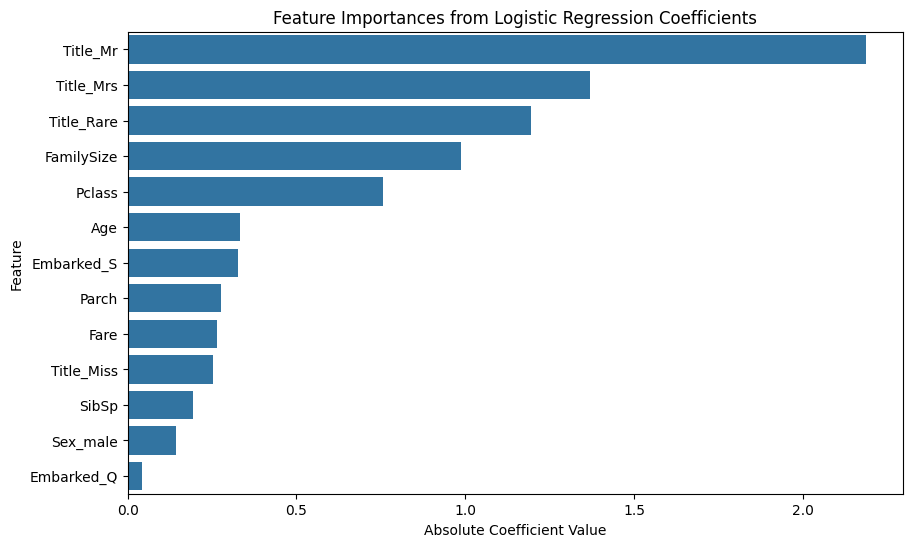

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from X_train
feature_names = X_train.columns

# Get coefficients from the trained model
coefficients = model.coef_[0]

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(coefficients)})

# Sort by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display the top features
print("Top 10 Feature Importances (absolute coefficients for Logistic Regression):")
display(feature_importance.head(10))

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importances from Logistic Regression Coefficients')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

The previous error was a `FileNotFoundError` because the dataset `train (1).csv` was not found. To resolve this and proceed with the data science pipeline, I will download a widely used `train.csv` dataset (the Titanic dataset) and update the loading path.

In [7]:
# Download the Titanic train dataset (a common dataset often named train.csv)
!wget -q https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O train.csv
print("Downloaded 'train.csv' (Titanic dataset) to /content/")

Downloaded 'train.csv' (Titanic dataset) to /content/


Conclusion
In this experiment, a complete data science pipeline was successfully implemented using
the Titanic Dataset. The process included data cleaning, exploratory data analysis (EDA),
feature engineering, encoding, scaling, and model building.
Through EDA, important patterns were observed, such as higher survival rates among
females and first-class passengers. Feature engineering was performed by creating new
features like FamilySize, which helped in improving the understanding of the data.
After preprocessing, a machine learning model was trained to predict survival. The
pipeline demonstrated how raw data can be transformed into meaningful insights and
predictions using systematic steps.
Overall, this experiment helped in understanding the importance of each stage in a data
science workflow and how proper preprocessing and feature selection improve model
performance